[*********************100%%**********************]  1 of 1 completed


Epoch 1/10
2738/2738 - 23s - loss: 0.0013 - 23s/epoch - 8ms/step
Epoch 2/10
2738/2738 - 21s - loss: 3.7836e-04 - 21s/epoch - 8ms/step
Epoch 3/10
2738/2738 - 22s - loss: 2.5616e-04 - 22s/epoch - 8ms/step
Epoch 4/10
2738/2738 - 22s - loss: 2.1951e-04 - 22s/epoch - 8ms/step
Epoch 5/10
2738/2738 - 21s - loss: 1.8145e-04 - 21s/epoch - 8ms/step
Epoch 6/10
2738/2738 - 22s - loss: 1.5756e-04 - 22s/epoch - 8ms/step
Epoch 7/10
2738/2738 - 21s - loss: 1.4336e-04 - 21s/epoch - 8ms/step
Epoch 8/10
2738/2738 - 22s - loss: 1.4959e-04 - 22s/epoch - 8ms/step
Epoch 9/10
2738/2738 - 22s - loss: 1.4346e-04 - 22s/epoch - 8ms/step
Epoch 10/10
2738/2738 - 22s - loss: 1.2786e-04 - 22s/epoch - 8ms/step
22/22 [==============================] - 0s 5ms/step
Root Mean Square Error: 2485.992316150953


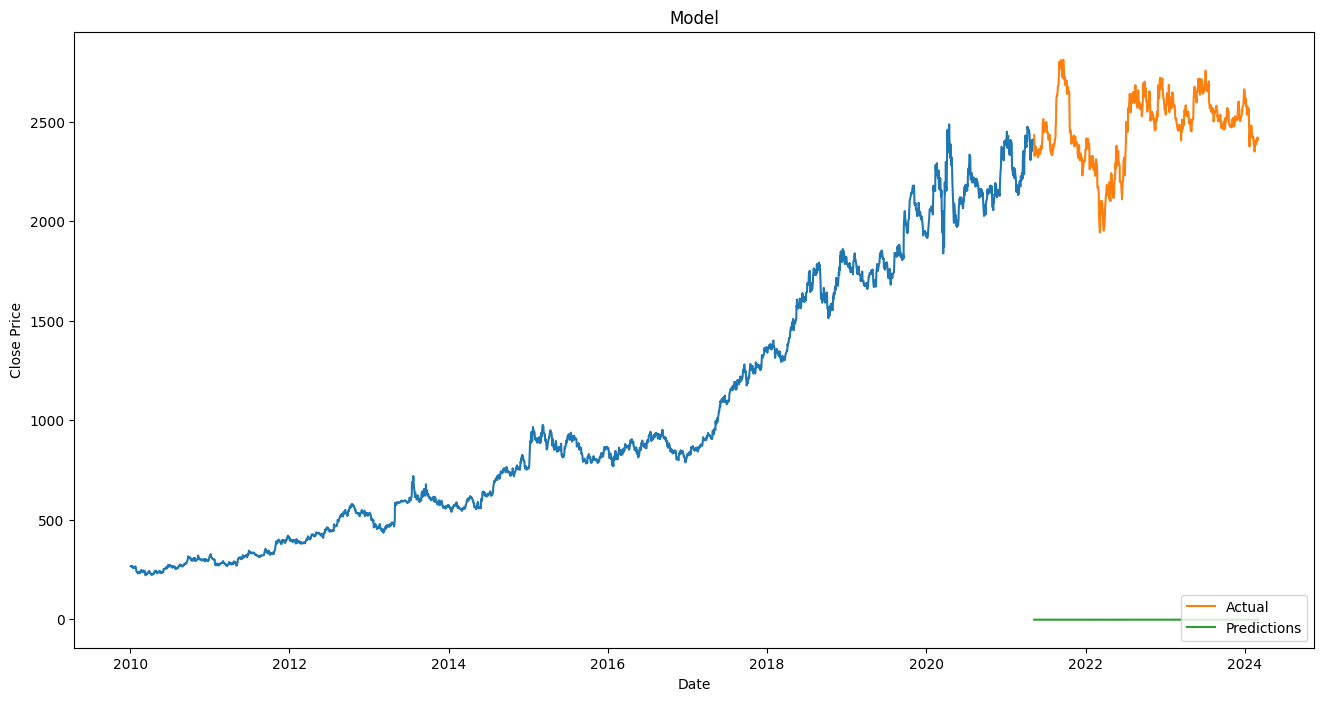

In [2]:
# Importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM

# Fetching historical data from Yahoo Finance
import yfinance as yf

# Define the ticker symbol
ticker_symbol = 'HINDUNILVR.NS'  # Example: Hindustan Unilever Ltd.

# Set the start and end dates for the historical data
start_date = '2010-01-01'
end_date = '2024-03-03'

# Fetch historical data from Yahoo Finance
df = yf.download(ticker_symbol, start=start_date, end=end_date)

# Reset the index to make 'Date' a column
df.reset_index(inplace=True)

# Creating a new DataFrame with 'Date' and 'Close' columns
data = df[['Date', 'Close']].copy()

# Setting the 'Date' column as the index
data.set_index('Date', inplace=True)

# Calculate the index to split the data (80% training, 20% validation)
split_index = int(0.8 * len(data))

# Creating train and test sets
train = data[:split_index]
valid = data[split_index:]

# Normalizing the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data.values)

# Creating x_train and y_train datasets
x_train, y_train = [], []
for i in range(60, len(train)):
    x_train.append(scaled_data[i-60:i, 0])
    y_train.append(scaled_data[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

# Reshaping the data for LSTM
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Building the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(LSTM(units=50))
model.add(Dense(1))

# Compiling the model
model.compile(loss='mean_squared_error', optimizer='adam')

# Fitting the model
model.fit(x_train, y_train, epochs=10, batch_size=1, verbose=2)

# Making predictions
inputs = scaled_data[len(scaled_data) - len(valid) - 60:]
inputs = inputs.reshape(-1, 1)
inputs = scaler.transform(inputs)

X_test = []
for i in range(60, inputs.shape[0]):
    X_test.append(inputs[i-60:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

closing_price = model.predict(X_test)
closing_price = scaler.inverse_transform(closing_price)

# Calculating RMSE
rms = np.sqrt(np.mean(np.power((valid.values - closing_price), 2)))
print("Root Mean Square Error:", rms)

# Plotting the results
plt.figure(figsize=(16, 8))
plt.title('Model')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.plot(train['Close'])
plt.plot(valid.index, valid['Close'], label='Actual')
plt.plot(valid.index, closing_price, label='Predictions')
plt.legend(loc='lower right')
plt.show()
